### Imports

In [1]:
import os, math, random, pickle
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report


import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input



2026-02-08 13:05:43.513624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770555943.695401      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770555943.746102      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770555944.185976      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770555944.186020      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770555944.186023      55 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_ROOT = Path("/kaggle/input/pharaohs-300-augmented")

train_dir = DATASET_ROOT / "augmented_train_300"
val_dir   = DATASET_ROOT / "validation_dataset_300"
test_dir  = DATASET_ROOT / "test_dataset_300"

print("Train dir:", train_dir)
print("Val dir  :", val_dir)
print("Test dir :", test_dir)

Train dir: /kaggle/input/pharaohs-300-augmented/augmented_train_300
Val dir  : /kaggle/input/pharaohs-300-augmented/validation_dataset_300
Test dir : /kaggle/input/pharaohs-300-augmented/test_dataset_300


### Helper Functions

In [3]:
IMG_EXTS = {".jpg", ".jpeg"}  

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def make_df(root: Path):
    rows = []
    for class_dir in list_subdirs(root):
        label = class_dir.name
        for p in class_dir.iterdir():
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({"label": label, "path": str(p)})
    return pd.DataFrame(rows, columns=["label", "path"])

def count_images_recursive(folder: Path):
    return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)

def count_per_class(root: Path, classes):
    out = {}
    for c in classes:
        out[c] = sum(1 for p in (root / c).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)
    return out


In [4]:
train_df = make_df(train_dir)
val_df   = make_df(val_dir)
test_df  = make_df(test_dir)

print("Train df:", train_df.shape)
print("Val df  :", val_df.shape)
print("Test df :", test_df.shape)

Train df: (20210, 2)
Val df  : (1395, 2)
Test df : (599, 2)


In [5]:
# classes from train 
classes = sorted(train_df["label"].unique().tolist())
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

# sanity: same class set in val/test
print("Val classes match train:",  set(val_df["label"].unique()) == set(classes))
print("Test classes match train:", set(test_df["label"].unique()) == set(classes))

Number of classes: 96
Sample classes: ['Achoris', 'Ahmose_I', 'Akhenaton', 'Alexander_the_Great', 'Amasis_II', 'Amenemhat_I', 'Amenemhat_III', 'Amenhotep_II', 'Amenhotep_III', 'Amenhotep_III_and_God_Re-Horakhty']
Val classes match train: True
Test classes match train: True


In [6]:
print("Train images:", count_images_recursive(train_dir))
print("Val images  :", count_images_recursive(val_dir))
print("Test images :", count_images_recursive(test_dir))


Train images: 20210
Val images  : 1395
Test images : 599


### EDA

#### Class Imbalance

In [7]:
train_counts = count_per_class(train_dir, classes)
val_counts   = count_per_class(val_dir, classes)

train_vals = np.array([train_counts[c] for c in classes])
val_vals   = np.array([val_counts[c] for c in classes])

In [8]:
print("Train min/max:", train_vals.min(), train_vals.max(),
      "\nratio:", train_vals.max() / max(1, train_vals.min()))
print("Val   min/max:", val_vals.min(), val_vals.max())

Train min/max: 144 300 
ratio: 2.0833333333333335
Val   min/max: 4 42


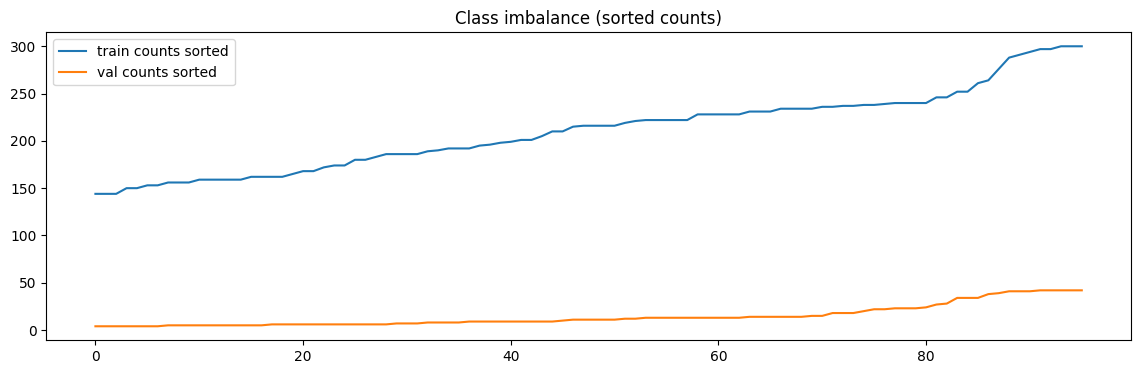

In [9]:
plt.figure(figsize=(14,4))
plt.plot(sorted(train_vals), label="train counts sorted")
plt.plot(sorted(val_vals), label="val counts sorted")
plt.legend()
plt.title("Class imbalance (sorted counts)")
plt.show()

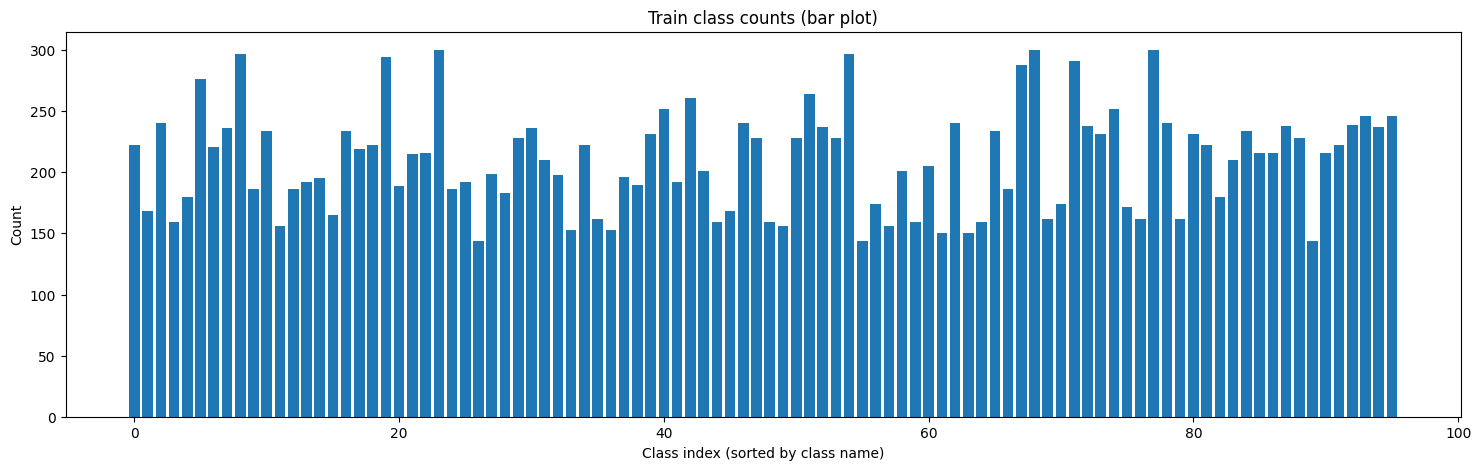

In [10]:
plt.figure(figsize=(18, 5))
plt.bar(range(len(classes)), train_vals)
plt.title("Train class counts (bar plot)")
plt.xlabel("Class index (sorted by class name)")
plt.ylabel("Count")
plt.show()

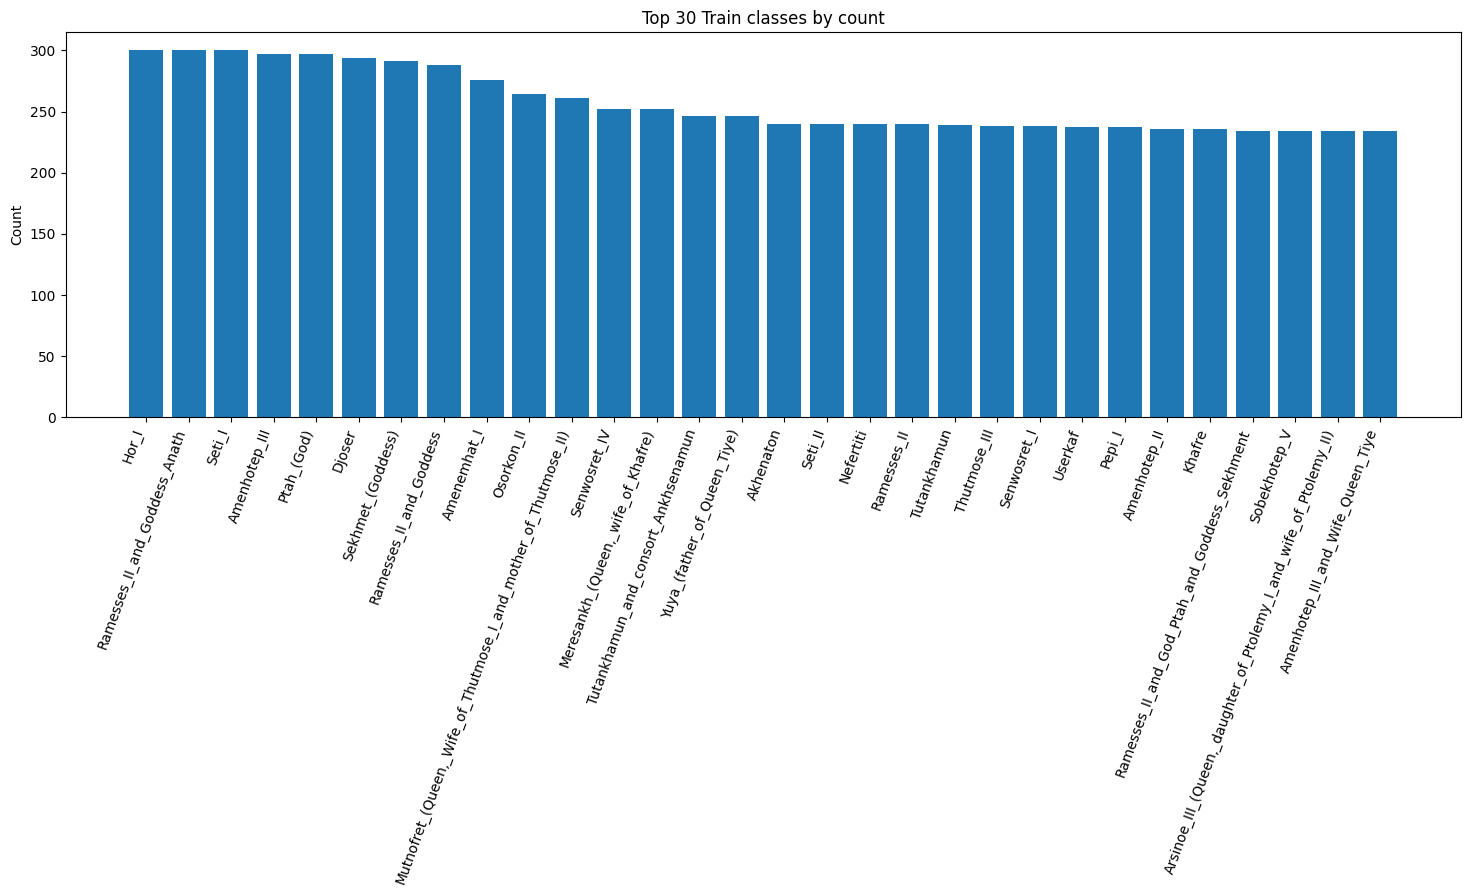

In [11]:
# plot top-30 most frequent
top_k = 30
sorted_idx = np.argsort(-train_vals)[:top_k]
plt.figure(figsize=(18, 5))
plt.bar([classes[i] for i in sorted_idx], train_vals[sorted_idx])
plt.title(f"Top {top_k} Train classes by count")
plt.xticks(rotation=70, ha="right")
plt.ylabel("Count")
plt.show()

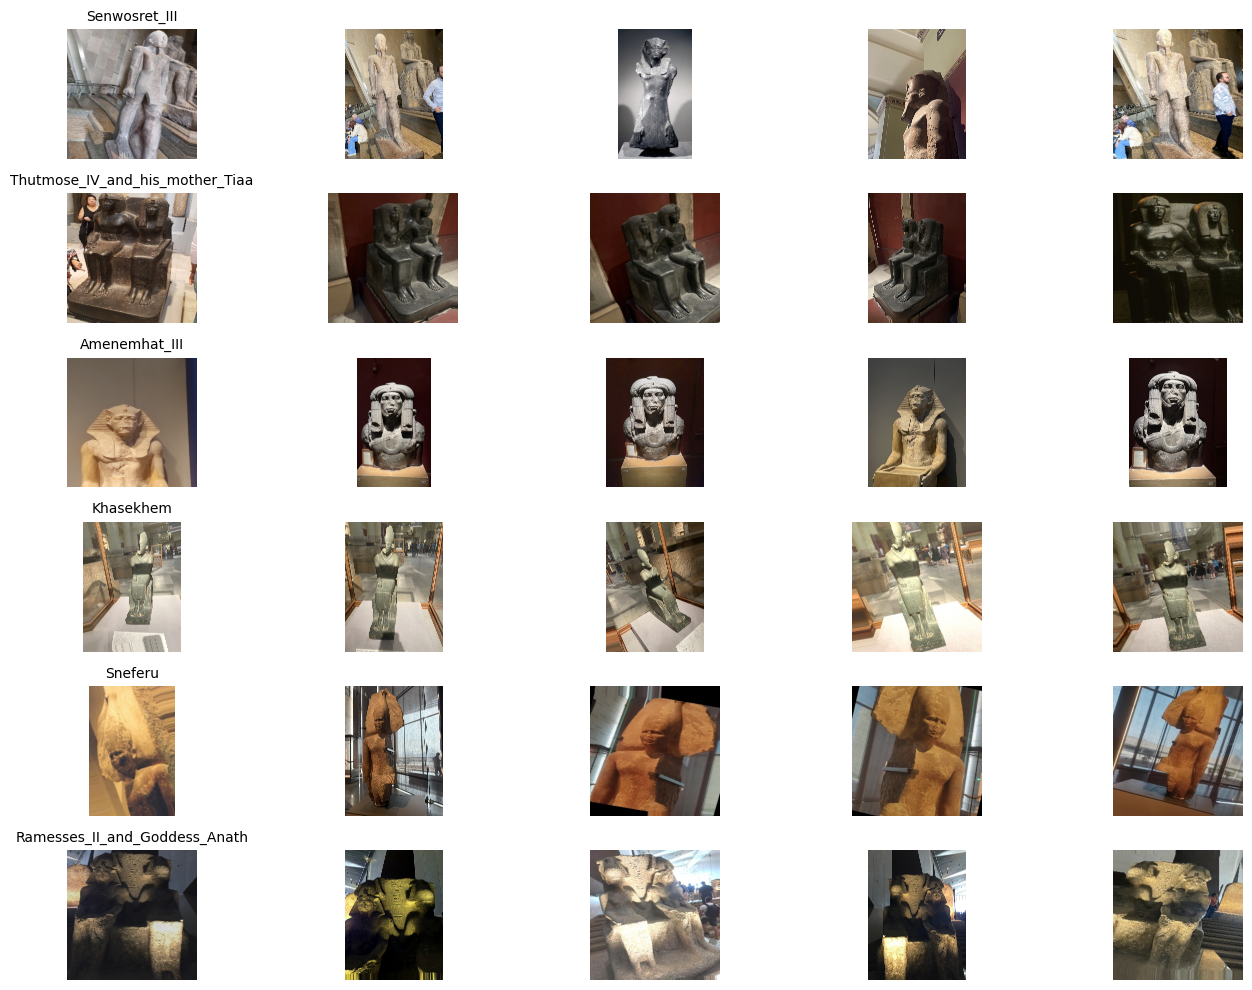

In [12]:
def show_samples_per_class(root: Path, class_names, k=5, rows=6):
    plt.figure(figsize=(14, 10))
    shown = 0
    picked = random.sample(class_names, min(len(class_names), rows))

    for cls in picked:
        imgs = [p for p in (root/cls).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
        if not imgs:
            continue
        for i in range(min(k, len(imgs))):
            img_path = str(random.choice(imgs))
            img = tf.keras.utils.load_img(img_path)
            ax = plt.subplot(rows, k, shown + 1)
            plt.imshow(img)
            plt.axis("off")
            if i == 0:
                ax.set_title(cls, fontsize=10)
            shown += 1
            if shown >= rows * k:
                break
        if shown >= rows * k:
            break

    plt.tight_layout()
    plt.show()

show_samples_per_class(train_dir, classes, k=5, rows=6)


### Pipeline

In [13]:
IMG_SIZE = 320
BATCH_SIZE = 24
NUM_CLASSES = 96  

AUTOTUNE = tf.data.AUTOTUNE

#### Label Encoding

In [14]:
encoder = LabelEncoder()

train_df["label_enc"] = encoder.fit_transform(train_df["label"])
val_df["label_enc"]   = encoder.transform(val_df["label"])
test_df["label_enc"]  = encoder.transform(test_df["label"])

NUM_CLASSES = len(encoder.classes_)
print("NUM_CLASSES:", NUM_CLASSES)

NUM_CLASSES: 96


#### Class Weights

In [15]:
y_train = train_df["label_enc"].values
classes_int = np.unique(y_train)

cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes_int,
    y=y_train)

In [16]:
cw

array([0.94829204, 1.2531002 , 0.87717014, 1.3240304 , 1.16956019,
       0.76275664, 0.95258296, 0.89203743, 0.70882435, 1.13183244,
       0.89966168, 1.34949252, 1.13183244, 1.09646267, 1.07959402,
       1.27588384, 0.89966168, 0.96128234, 0.94829204, 0.71605726,
       1.11386684, 0.97916667, 0.97463349, 0.70173611, 1.13183244,
       1.09646267, 1.46195023, 1.05789363, 1.15038707, 0.92333699,
       0.89203743, 1.00248016, 1.06323653, 1.37595316, 0.94829204,
       1.29951132, 1.37595316, 1.07408588, 1.10800439, 0.9113456 ,
       0.83540013, 1.09646267, 0.80659323, 1.04736733, 1.3240304 ,
       1.2531002 , 0.87717014, 0.92333699, 1.3240304 , 1.34949252,
       0.92333699, 0.7974274 , 0.88827356, 0.92333699, 0.70882435,
       1.46195023, 1.20988985, 1.34949252, 1.04736733, 1.3240304 ,
       1.02693089, 1.40347222, 0.87717014, 1.40347222, 1.3240304 ,
       0.89966168, 1.13183244, 0.73097512, 0.70173611, 1.29951132,
       1.20988985, 0.72343929, 0.88454132, 0.9113456 , 0.83540

In [17]:
cw_dict = {int(c): float(w) for c, w in zip(classes_int, cw)}

In [18]:
cw_dict

{0: 0.9482920420420421,
 1: 1.2531001984126984,
 2: 0.8771701388888888,
 3: 1.3240303983228512,
 4: 1.1695601851851851,
 5: 0.7627566425120773,
 6: 0.9525829562594268,
 7: 0.892037429378531,
 8: 0.708824354657688,
 9: 1.1318324372759856,
 10: 0.8996616809116809,
 11: 1.3494925213675213,
 12: 1.1318324372759856,
 13: 1.0964626736111112,
 14: 1.079594017094017,
 15: 1.2758838383838385,
 16: 0.8996616809116809,
 17: 0.9612823439878234,
 18: 0.9482920420420421,
 19: 0.7160572562358276,
 20: 1.1138668430335097,
 21: 0.9791666666666666,
 22: 0.974633487654321,
 23: 0.7017361111111111,
 24: 1.1318324372759856,
 25: 1.0964626736111112,
 26: 1.4619502314814814,
 27: 1.057893634840871,
 28: 1.150387067395264,
 29: 0.9233369883040936,
 30: 0.892037429378531,
 31: 1.0024801587301588,
 32: 1.063236531986532,
 33: 1.3759531590413943,
 34: 0.9482920420420421,
 35: 1.299511316872428,
 36: 1.3759531590413943,
 37: 1.0740858843537415,
 38: 1.1080043859649122,
 39: 0.9113455988455988,
 40: 0.835400132275

In [19]:
cw_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
for c, w in cw_dict.items():
    cw_vec[int(c)] = float(w)

cw_tf = tf.constant(cw_vec, dtype=tf.float32)
print("Example weights:", list(cw_dict.items())[:10])

Example weights: [(0, 0.9482920420420421), (1, 1.2531001984126984), (2, 0.8771701388888888), (3, 1.3240303983228512), (4, 1.1695601851851851), (5, 0.7627566425120773), (6, 0.9525829562594268), (7, 0.892037429378531), (8, 0.708824354657688), (9, 1.1318324372759856)]


I0000 00:00:1770556069.069113      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


#### EfficientNet preprocessing

##### On-the-fly Augmentation

In [20]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08,fill_mode="reflect"),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.08, 0.08, fill_mode="reflect"),
], name="data_aug")

In [21]:
class TFDataset:
    def __init__(self, df, batch_size=BATCH_SIZE, shuffle=True, image_size=IMG_SIZE, augment=False):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_raw(self, path, label):
        img = tf.io.read_file(path)          # path is a tf.string tensor (bytes)
        img = tf.image.decode_jpeg(img, channels=3)   # decode jpg -> uint8 [0..255]
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, (self.image_size, self.image_size), method="bilinear")  #resize
        img = tf.cast(img, tf.float32)  
        label = tf.cast(label, tf.int32)   # keep integer label for now
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label_enc"].values.astype(np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(self._load_raw, num_parallel_calls=AUTOTUNE)

        if self.shuffle:
            ds = ds.shuffle(buffer_size= min(len(self.df), 5000), reshuffle_each_iteration=True)

        if self.augment:
            ds = ds.map(lambda x, y: (data_aug(x, training=True), y),num_parallel_calls=AUTOTUNE)

        ds = ds.batch(self.batch_size)
        
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))


##### MixUp

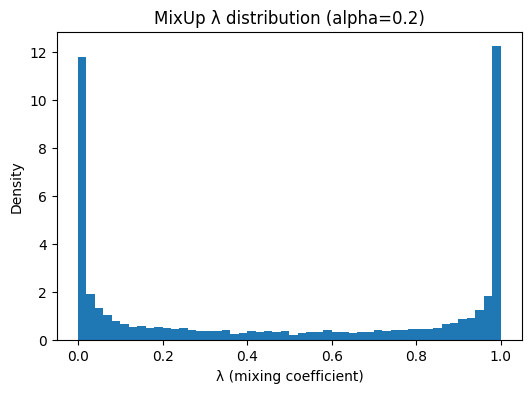

In [22]:
#  λ distribution
# plot to justify MixUp hyperparameter choice (α).
alpha = 0.2
N = 10000

lam = np.random.beta(alpha, alpha, N)

plt.figure(figsize=(6,4))
plt.hist(lam, bins=50, density=True)
plt.xlabel("λ (mixing coefficient)")
plt.ylabel("Density")
plt.title(f"MixUp λ distribution (alpha={alpha})")
plt.show()

In [23]:
MIXUP_ALPHA = 0.2

def _sample_beta(alpha, shape):
    g1 = tf.random.gamma(shape, alpha)
    g2 = tf.random.gamma(shape, alpha)
    return g1 / (g1 + g2)

def _to_onehot(labels_int):
    return tf.one_hot(labels_int, NUM_CLASSES, dtype=tf.float32)

def _sample_weight_from_onehot(y_onehot):
    # expected weight per sample: sum_j y_j * w_j
    return tf.reduce_sum(y_onehot * cw_tf[None, :], axis=1)  # (B,)


In [24]:
def mixup_batch(images, labels_int):
    B = tf.shape(images)[0]
    y1 = _to_onehot(labels_int)

    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(images, idx)
    y2 = tf.gather(y1, idx)

    lam = _sample_beta(MIXUP_ALPHA, [B])
    lam_x = tf.reshape(lam, [B, 1, 1, 1])
    lam_y = tf.reshape(lam, [B, 1])

    x = images * lam_x + x2 * (1.0 - lam_x)
    y = y1 * lam_y + y2 * (1.0 - lam_y)

    sw = _sample_weight_from_onehot(y)
    return x, y, sw

In [25]:
def plain_batch_train(images, labels_int):
    y = _to_onehot(labels_int)
    sw = _sample_weight_from_onehot(y)
    return images, y, sw

def plain_batch_eval(images, labels_int):
    y = _to_onehot(labels_int)
    sw = tf.ones([tf.shape(images)[0]], tf.float32)
    return images, y, sw

def maybe_mixup(images, labels_int, mixup_prob):
    mixup_prob = tf.cast(mixup_prob, tf.float32)
    do = tf.random.uniform([]) < mixup_prob
    return tf.cond(
        do,
        lambda: mixup_batch(images, labels_int),
        lambda: plain_batch_train(images, labels_int),
    )


In [26]:
def mobilenetv3_normalize(x, y, sw):
    # MobileNetV3 preprocess_input handles scaling appropriately
    x = preprocess_input(x)
    return x, y, sw


In [27]:
def apply_aug(x, y):
    return data_aug(x, training=True), y

In [28]:
base_ds = TFDataset(train_df, augment=False, shuffle=True).dataset

# Phase A: NO MixUp (prob = 0)
train_ds = (
    base_ds
    .map(apply_aug, num_parallel_calls=AUTOTUNE)
    .map(plain_batch_train, num_parallel_calls=AUTOTUNE)
    .map(mobilenetv3_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)  
)

# Phase B: MixUp ON (light)
MIXUP_PROB  = 0.15
train_ds_mix = (
    base_ds
    .map(apply_aug, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: maybe_mixup(x, y, MIXUP_PROB), num_parallel_calls=AUTOTUNE)
    .map(mobilenetv3_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


# Val/Test: no MixUp, no class-weight sample weights (keep eval setting)
val_ds = (
    TFDataset(val_df, augment=False, shuffle=False).dataset
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .map(mobilenetv3_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    TFDataset(test_df, augment=False, shuffle=False).dataset
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .map(mobilenetv3_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


In [29]:
#Sanity Check

# Train Stage 1 batch
x, y, sw = next(iter(train_ds.take(1)))
print("train_ds:", x.shape, y.shape, sw.shape, y.dtype, sw.dtype)

# Train Stage 2 batch
x2, y2, sw2 = next(iter(train_ds_mix.take(1)))
print("train_ds_mix:", x2.shape, y2.shape, sw2.shape, y2.dtype, sw2.dtype)

# Validation batch
xv, yv, swv = next(iter(val_ds.take(1)))
print("val_ds:", xv.shape, yv.shape, swv.shape, yv.dtype, swv.dtype)

train_ds: (24, 320, 320, 3) (24, 96) (24,) <dtype: 'float32'> <dtype: 'float32'>
train_ds_mix: (24, 320, 320, 3) (24, 96) (24,) <dtype: 'float32'> <dtype: 'float32'>
val_ds: (24, 320, 320, 3) (24, 96) (24,) <dtype: 'float32'> <dtype: 'float32'>


#### Model

In [30]:
base = tf.keras.applications.MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling=None
)

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [31]:
def build_model(base,img_size=IMG_SIZE):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(256, activation="gelu")(x)
    x = layers.Dropout(0.25)(x)
    
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs, outputs)
    
    return model


#### Training 

##### Stage 1: warm up head (freeze backbone)

In [32]:
base.trainable = False
model = build_model(base, IMG_SIZE)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 10, 10, 960)    │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 960)            │         1,920 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,268,960 (12.47 MB)

 Trainable params: 272,608 (1.04 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [33]:
EPOCHS_A= 10

In [34]:
print(train_ds.element_spec)
print(val_ds.element_spec)
print(test_ds.element_spec)


(TensorSpec(shape=(None, 320, 320, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 320, 320, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 320, 320, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [35]:
ckpt1 = ModelCheckpoint(
    "mobilenetv3_stage1_best.keras",
    monitor="val_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early1 = EarlyStopping(
    monitor="val_loss",
    patience=6,
    mode="min",
    restore_best_weights=True,
    verbose=1,
)

reduce1 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    mode="min",
    min_lr=1e-6,
    verbose=1
)

In [36]:
# stabilizes training before fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["categorical_accuracy"]
)

history1 = model.fit(
    train_ds,                   
    validation_data=val_ds,
    epochs=EPOCHS_A,
    callbacks=[ckpt1, early1, reduce1],
    verbose=1
)


Epoch 1/10


I0000 00:00:1770556397.313606     122 service.cc:152] XLA service 0x78e8941435e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770556397.313653     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770556399.536976     122 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770556410.722753     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


843/843 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - categorical_accuracy: 0.5435 - loss: 2.2388
Epoch 1: val_categorical_accuracy improved from -inf to 0.73405, saving model to mobilenetv3_stage1_best.keras
843/843 ━━━━━━━━━━━━━━━━━━━━ 710s 706ms/step - categorical_accuracy: 0.5436 - loss: 2.2382 - val_categorical_accuracy: 0.7341 - val_loss: 1.2434 - learning_rate: 3.0000e-04
Epoch 2/10
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - categorical_accuracy: 0.8597 - loss: 0.7567
Epoch 2: val_categorical_accuracy improved from 0.73405 to 0.84516, saving model to mobilenetv3_stage1_best.keras
843/843 ━━━━━━━━━━━━━━━━━━━━ 653s 661ms/step - categorical_accuracy: 0.8597 - loss: 0.7565 - val_categorical_accuracy: 0.8452 - val_loss: 0.8266 - learning_rate: 3.0000e-04
Epoch 3/10
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - categorical_accuracy: 0.9240 - loss: 0.5351
Epoch 3: val_categorical_accuracy improved from 0.84516 to 0.86953, saving model to mobilenetv3_stage1_best.keras
843/843 ━━━━━━━━━━━━━━━━━━

In [37]:
model.save("/kaggle/working/300Version_MobileNetV3_stage1_noMixup.keras")

##### Stage 2: fine-tune backbone 

In [38]:
EPOCHS_B1 = 12
EPOCHS_B2 = 3

In [39]:
base.trainable = True
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

In [40]:
ckpt2 = ModelCheckpoint(
    "mobilenetv3_stage2a_best.keras",
    monitor="val_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)
early2 = EarlyStopping(
    monitor="val_categorical_accuracy",
    patience=6,
    mode="max",
    restore_best_weights=True,
    verbose=1,
)

In [41]:
steps_per_epoch = tf.data.experimental.cardinality(train_ds_mix).numpy()
decay_steps = steps_per_epoch * EPOCHS_B1  

cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-5,
    decay_steps=decay_steps,
    alpha=0.05
)


##### B1

In [42]:
# lower LR for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=cosine_lr, weight_decay=3e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["categorical_accuracy"]
)

history2 = model.fit(
    train_ds_mix,
    validation_data=val_ds,
    epochs=EPOCHS_A + EPOCHS_B1,
    initial_epoch=EPOCHS_A,
    callbacks=[ckpt2, early2]
)

Epoch 11/22


2026-02-08 15:05:19.050594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-08 15:05:19.251310: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-08 15:05:19.785633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-08 15:05:19.996038: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - categorical_accuracy: 0.9804 - loss: 0.4177

2026-02-08 15:14:27.479587: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-08 15:14:27.685886: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


843/843 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - categorical_accuracy: 0.9804 - loss: 0.4177
Epoch 11: val_categorical_accuracy improved from -inf to 0.94194, saving model to mobilenetv3_stage2a_best.keras
843/843 ━━━━━━━━━━━━━━━━━━━━ 738s 699ms/step - categorical_accuracy: 0.9804 - loss: 0.4177 - val_categorical_accuracy: 0.9419 - val_loss: 0.4733
Epoch 12/22
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - categorical_accuracy: 0.9821 - loss: 0.4147
Epoch 12: val_categorical_accuracy improved from 0.94194 to 0.95269, saving model to mobilenetv3_stage2a_best.keras
843/843 ━━━━━━━━━━━━━━━━━━━━ 676s 680ms/step - categorical_accuracy: 0.9822 - loss: 0.4147 - val_categorical_accuracy: 0.9527 - val_loss: 0.4449
Epoch 13/22
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - categorical_accuracy: 0.9852 - loss: 0.3905
Epoch 13: val_categorical_accuracy did not improve from 0.95269
843/843 ━━━━━━━━━━━━━━━━━━━━ 685s 689ms/step - categorical_accuracy: 0.9853 - loss: 0.3905 - val_categorical_accuracy: 0.9505 

In [43]:
model.save("/kaggle/working/300Version_MobileNetV3_stage2a_withMixUp.keras")

##### B2

In [44]:
ckpt3 = ModelCheckpoint(
    "mobilenetv3_stage2b_best.keras",
    monitor="val_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

In [45]:
history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_A + EPOCHS_B1 + EPOCHS_B2,
    initial_epoch=EPOCHS_A + EPOCHS_B1,
    callbacks=[ckpt3],  
)

Epoch 23/25
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - categorical_accuracy: 0.9987 - loss: 0.2451
Epoch 23: val_categorical_accuracy improved from -inf to 0.96272, saving model to mobilenetv3_stage2b_best.keras
843/843 ━━━━━━━━━━━━━━━━━━━━ 683s 677ms/step - categorical_accuracy: 0.9987 - loss: 0.2451 - val_categorical_accuracy: 0.9627 - val_loss: 0.3802
Epoch 24/25
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - categorical_accuracy: 0.9992 - loss: 0.2411
Epoch 24: val_categorical_accuracy did not improve from 0.96272
843/843 ━━━━━━━━━━━━━━━━━━━━ 678s 671ms/step - categorical_accuracy: 0.9992 - loss: 0.2411 - val_categorical_accuracy: 0.9627 - val_loss: 0.3777
Epoch 25/25
842/843 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - categorical_accuracy: 0.9993 - loss: 0.2405
Epoch 25: val_categorical_accuracy improved from 0.96272 to 0.96487, saving model to mobilenetv3_stage2b_best.keras
843/843 ━━━━━━━━━━━━━━━━━━━━ 675s 668ms/step - categorical_accuracy: 0.9993 - loss: 0.2405 - val_categorical_accur

In [46]:
model.save("/kaggle/working/300Version_MobileNetV3_stage2b_noMixUp.keras")

### Results 

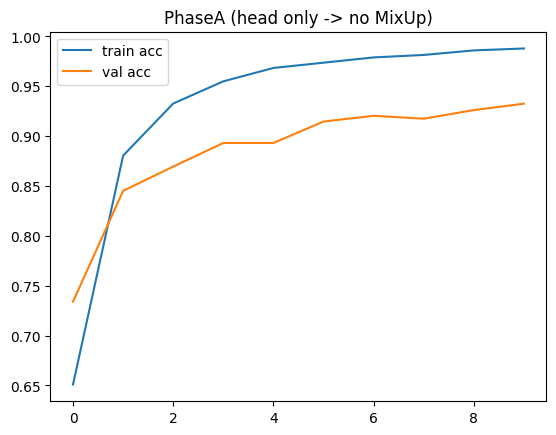

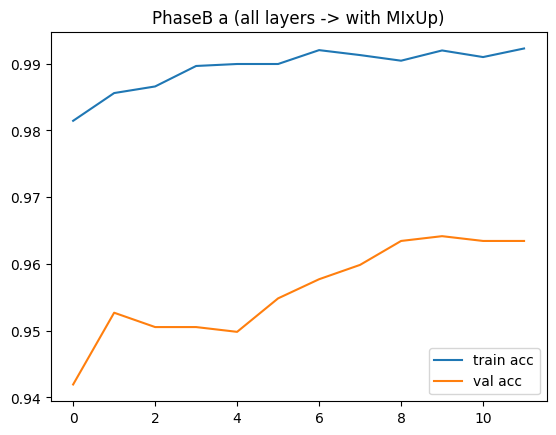

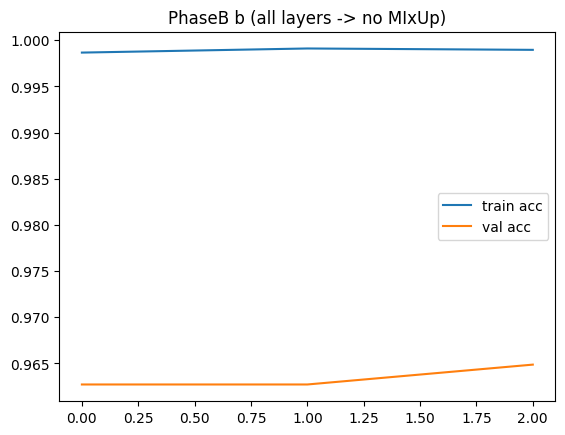

In [47]:
def plot_history(h, title):
    plt.figure()
    plt.plot(h.history["categorical_accuracy"], label="train acc")
    plt.plot(h.history["val_categorical_accuracy"], label="val acc")
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(history1, "PhaseA (head only -> no MixUp)")
plot_history(history2, "PhaseB a (all layers -> with MIxUp)")
plot_history(history3, "PhaseB b (all layers -> no MIxUp)")

In [48]:
final_train_loss = history1.history["loss"][-1]
final_val_loss   = history1.history["val_loss"][-1]

final_train_acc = history1.history["categorical_accuracy"][-1]
final_val_acc   = history1.history["val_categorical_accuracy"][-1]

print("Final Train accuracy: ", final_train_acc * 100)
print("Final Train loss: ", final_train_loss)
print("Final Validation accuracy: ", final_val_acc * 100)
print("Final Validation loss: ", final_val_loss)


Final Train accuracy:  98.79762530326843
Final Train loss:  0.30453211069107056
Final Validation accuracy:  93.26164722442627
Final Validation loss:  0.5098810791969299


In [49]:
final_train_loss = history2.history["loss"][-1]
final_val_loss   = history2.history["val_loss"][-1]

final_train_acc = history2.history["categorical_accuracy"][-1]
final_val_acc   = history2.history["val_categorical_accuracy"][-1]

print("Final Train accuracy: ", final_train_acc * 100)
print("Final Train loss: ", final_train_loss)
print("Final Validation accuracy: ", final_val_acc * 100)
print("Final Validation loss: ", final_val_loss)


Final Train accuracy:  99.22810196876526
Final Train loss:  0.33669599890708923
Final Validation accuracy:  96.34408354759216
Final Validation loss:  0.38021379709243774


In [50]:
final_train_loss = history3.history["loss"][-1]
final_val_loss   = history3.history["val_loss"][-1]

final_train_acc = history3.history["categorical_accuracy"][-1]
final_val_acc   = history3.history["val_categorical_accuracy"][-1]

print("Final Train accuracy: ", final_train_acc * 100)
print("Final Train loss: ", final_train_loss)
print("Final Validation accuracy: ", final_val_acc * 100)
print("Final Validation loss: ", final_val_loss)

Final Train accuracy:  99.89609122276306
Final Train loss:  0.23924808204174042
Final Validation accuracy:  96.48745656013489
Final Validation loss:  0.37915095686912537


In [51]:
best_epoch = np.argmin(history1.history["val_loss"])
best_val_loss = history1.history["val_loss"][best_epoch]
best_val_acc  = history1.history["val_categorical_accuracy"][best_epoch]

print("Best epoch:", best_epoch + 1)
print("Best val loss:", best_val_loss)
print("Best val acc:", best_val_acc * 100)

Best epoch: 10
Best val loss: 0.5098810791969299
Best val acc: 93.26164722442627


In [52]:
best_epoch = np.argmin(history2.history["val_loss"])
best_val_loss = history2.history["val_loss"][best_epoch]
best_val_acc  = history2.history["val_categorical_accuracy"][best_epoch]

print("Best epoch:", best_epoch + 1)
print("Best val loss:", best_val_loss)
print("Best val acc:", best_val_acc * 100)

Best epoch: 12
Best val loss: 0.38021379709243774
Best val acc: 96.34408354759216


In [53]:
best_epoch = np.argmin(history3.history["val_loss"])
best_val_loss = history3.history["val_loss"][best_epoch]
best_val_acc  = history3.history["val_categorical_accuracy"][best_epoch]

print("Best epoch:", best_epoch + 1)
print("Best val loss:", best_val_loss)
print("Best val acc:", best_val_acc * 100)

Best epoch: 2
Best val loss: 0.3776519298553467
Best val acc: 96.27240300178528


In [54]:
# Evaluate “restored best” properly
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)
test_loss, test_acc   = model.evaluate(test_ds, verbose=0)

print("Restored Train acc:", train_acc * 100)
print("Restored Val   acc:", val_acc * 100)
print("Restored Test  acc:", test_acc * 100)


Restored Train acc: 99.94556903839111
Restored Val   acc: 96.48745656013489
Restored Test  acc: 97.82971739768982


#### Confusion matrix + classification report

In [55]:
y_true, y_pred = [], []

for xb, yb, swb in val_ds:   
    preds = model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1).tolist())

    yb_np = yb.numpy()
    if yb_np.ndim > 1 and yb_np.shape[-1] > 1:
        yb_np = np.argmax(yb_np, axis=1)

    y_true.extend(yb_np.astype(int).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
print("Val accuracy:", (y_true == y_pred).mean())
print(classification_report(y_true, y_pred,labels=np.arange(len(classes)),target_names=classes,digits=4))


Val accuracy: 0.9648745519713262
                                                                   precision    recall  f1-score   support

                                                          Achoris     1.0000    1.0000    1.0000        13
                                                         Ahmose_I     1.0000    1.0000    1.0000         5
                                                        Akhenaton     0.9762    0.9762    0.9762        42
                                              Alexander_the_Great     1.0000    0.7778    0.8750         9
                                                        Amasis_II     1.0000    1.0000    1.0000         5
                                                      Amenemhat_I     1.0000    1.0000    1.0000         8
                                                    Amenemhat_III     1.0000    0.9487    0.9737        39
                                                     Amenhotep_II     1.0000    1.0000    1.0000        41
   

#### confusion matrix for most confused classes

In [56]:
support = cm.sum(axis=1)          # number of true samples per class
cm_norm = cm / support[:, None]  # row-normalized confusion rates
confusions = []

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            confusions.append((
                cm[i, j],           # count
                cm_norm[i, j],      # rate
                classes[i],         # true
                classes[j]          # predicted
            ))


confusions.sort(reverse=True)       #sorted by count

print("Top confusions:")
for count, rate, true, pred in confusions[:15]:
    print(f"{true} -> {pred} : {count} ({rate*100:.2f}%)")


Top confusions:
Mentuhotep_II -> Senwosret_I : 5 (21.74%)
Ptolemy_II_Philadelphus -> Cleopatra_VII_Philopator : 2 (40.00%)
Menkaure_and_his_wife_(likely_Queen_Khamerernebty_II) -> Thutmose_III : 2 (33.33%)
Hathor_(Goddess) -> Isis_(Goddess) : 2 (18.18%)
Amenemhat_III -> Thutmose_III : 2 (5.13%)
Isis_(Goddess) -> Anubis_(God) : 1 (25.00%)
Sobekemsaf_I -> Ramesses_II : 1 (20.00%)
Shepsekaf -> Amenhotep_III : 1 (20.00%)
Ptolemy_II_Philadelphus -> Ramesses_II : 1 (20.00%)
Thutmose_IV -> Cleopatra_VII_Philopator : 1 (16.67%)
Mut_(Goddess) -> Teti : 1 (16.67%)
Mut_(Goddess) -> Seti_II : 1 (16.67%)
Cleopatra_VII_Philopator -> Sekhmet_(Goddess) : 1 (16.67%)
Amun_(God) -> Raneferef : 1 (16.67%)
Osiris_(God) -> Hatshepsut : 1 (14.29%)


In [57]:
support = cm.sum(axis=1)
cm_norm = cm / support[:, None]

print("All confusions (non-zero):")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            print(
                f"{classes[i]} → {classes[j]} : "
                f"{cm[i,j]}/{support[i]} "
                f"({cm_norm[i,j]*100:.2f}%)"
            )


All confusions (non-zero):
Akhenaton → Ramesses_II : 1/42 (2.38%)
Alexander_the_Great → Akhenaton : 1/9 (11.11%)
Alexander_the_Great → Ptolemy_III_Euergetes : 1/9 (11.11%)
Amenemhat_III → Thutmose_III : 2/39 (5.13%)
Amenhotep_III → Hatshepsut : 1/34 (2.94%)
Amenhotep_III → Senwosret_I : 1/34 (2.94%)
Amenirdis_(Daughter_of_Kashta) → Thutmose_III : 1/9 (11.11%)
Amun_(God) → Raneferef : 1/6 (16.67%)
Arsinoe_II_(Queen,_sister_and_wife_of_Ptolemy_IV) → Cleopatra_VII_Philopator : 1/13 (7.69%)
Arsinoe_II_(Queen,_sister_and_wife_of_Ptolemy_IV) → Ptolemy_III_Euergetes : 1/13 (7.69%)
Cleopatra_VII_Philopator → Sekhmet_(Goddess) : 1/6 (16.67%)
Djoser → Khafre : 1/34 (2.94%)
Hathor_(Goddess) → Isis_(Goddess) : 2/11 (18.18%)
Hathor_(Goddess) → Yuya_(father_of_Queen_Tiye) : 1/11 (9.09%)
Isis_(Goddess) → Anubis_(God) : 1/4 (25.00%)
Khafre → Amenhotep_III_and_Wife_Queen_Tiye : 1/41 (2.44%)
Khonsu_(God) → Ptah_(God) : 1/12 (8.33%)
Menkaure_and_his_wife_(likely_Queen_Khamerernebty_II) → Thutmose_III : 2

### Test Inference

In [58]:
y_true, y_pred = [], []

for xb, yb, swb in test_ds:
    preds = model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

    y_true.extend(np.argmax(yb.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# accuracy
test_acc = (y_true == y_pred).mean()
print(f"Test accuracy: {test_acc:.8f}")

# report
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm_test = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm_test.shape)
print("\nConfusion Matrix:\n", cm_test)

Test accuracy: 0.97829716
                                                                   precision    recall  f1-score   support

                                                          Achoris       1.00      1.00      1.00         6
                                                         Ahmose_I       1.00      1.00      1.00         2
                                                        Akhenaton       1.00      1.00      1.00        18
                                              Alexander_the_Great       0.80      1.00      0.89         4
                                                        Amasis_II       1.00      1.00      1.00         2
                                                      Amenemhat_I       1.00      1.00      1.00         4
                                                    Amenemhat_III       1.00      1.00      1.00        16
                                                     Amenhotep_II       1.00      0.94      0.97        18
          

In [59]:
print(f"Test accuracy: {test_acc*100:.8f}")

Test accuracy: 97.82971619


In [60]:
#Evaluate 
OUT_DIR="/kaggle/working/"
ckpt_path = os.path.join(OUT_DIR, "mobilenetv3_stage1_best.keras")
model = tf.keras.models.load_model(ckpt_path)

val_loss, val_acc= model.evaluate(val_ds, verbose=1)
print("VAL  loss:", val_loss, "acc:", val_acc)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print("TEST loss:", test_loss, "acc:", test_acc)


59/59 ━━━━━━━━━━━━━━━━━━━━ 42s 558ms/step - categorical_accuracy: 0.9111 - loss: 0.5806
VAL  loss: 0.5098810791969299 acc: 0.9326164722442627
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 746ms/step - categorical_accuracy: 0.9380 - loss: 0.4723
TEST loss: 0.4429508149623871 acc: 0.9482470750808716


In [62]:
#Evaluate 
OUT_DIR="/kaggle/working"
ckpt_path = os.path.join(OUT_DIR, "mobilenetv3_stage2a_best.keras")
model = tf.keras.models.load_model(ckpt_path)

val_loss, val_acc= model.evaluate(val_ds, verbose=1)
print("VAL  loss:", val_loss, "acc:", val_acc)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print("TEST loss:", test_loss, "acc:", test_acc)


59/59 ━━━━━━━━━━━━━━━━━━━━ 41s 535ms/step - categorical_accuracy: 0.9600 - loss: 0.4107
VAL  loss: 0.3876638412475586 acc: 0.9641577005386353
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 773ms/step - categorical_accuracy: 0.9774 - loss: 0.3357
TEST loss: 0.333822637796402 acc: 0.9782971739768982


In [63]:
#Evaluate 
OUT_DIR="/kaggle/working"
ckpt_path = os.path.join(OUT_DIR, "mobilenetv3_stage2b_best.keras")
model = tf.keras.models.load_model(ckpt_path)

val_loss, val_acc= model.evaluate(val_ds, verbose=1)
print("VAL  loss:", val_loss, "acc:", val_acc)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print("TEST loss:", test_loss, "acc:", test_acc)

59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 537ms/step - categorical_accuracy: 0.9625 - loss: 0.3941
VAL  loss: 0.37915095686912537 acc: 0.9648745656013489
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 777ms/step - categorical_accuracy: 0.9808 - loss: 0.3265
TEST loss: 0.32808491587638855 acc: 0.9782971739768982


In [64]:
support_test = cm_test.sum(axis=1)
cm_norm_test = cm_test / support_test[:, None]

print("All confusions (non-zero):")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        if i != j and cm_test[i, j] > 0:
            print(
                f"{classes[i]} → {classes[j]} : "
                f"{cm_test[i,j]}/{support_test[i]} "
                f"({cm_norm_test[i,j]*100:.2f}%)"
            )


All confusions (non-zero):
Amenhotep_II → Thutmose_III : 1/18 (5.56%)
Amenhotep_III → Senwosret_III : 1/15 (6.67%)
Cleopatra_VII_Philopator → Menkaure_and_his_wife_(likely_Queen_Khamerernebty_II) : 1/3 (33.33%)
Isis_(Goddess) → Isis_(mother_of_Thutmose_III) : 1/2 (50.00%)
Mentuhotep_II → Senwosret_I : 2/10 (20.00%)
Nofret_(Queen,_possibly_Nofret_II,_wife_of_Senusret_II) → Sekhmet_(Goddess) : 1/4 (25.00%)
Ptah_(God) → Hatshepsut : 1/7 (14.29%)
Ra-Horakhty_(God) → Thutmose_III : 1/10 (10.00%)
Ramesses_II → Hatshepsut : 1/18 (5.56%)
Sobekhotep_V → Sobekhotep_IV : 1/6 (16.67%)
Thutmose_III → Amenhotep_III : 1/18 (5.56%)
Tiye_(Queen,_wife_of_Amenhotep_III) → Alexander_the_Great : 1/3 (33.33%)


In [65]:
#sorted by rate
support_test = cm_test.sum(axis=1)
cm_norm_test = cm_test / support_test[:, None]
all_confusions_test =[]

print("All confusions (non-zero):")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        if i != j and cm_test[i, j] > 0:
           all_confusions_test.append((cm_norm_test[i,j], cm_test[i,j], classes[i], classes[j]))

all_confusions_test.sort(reverse=True) # sorts by rate first

print("Top confusions by RATE:")
for rate, count, true, pred in all_confusions_test:
    print(f"{true} → {pred} :  {count}/{support_test[classes.index(true)]} ({rate*100:.2f}%)")

All confusions (non-zero):
Top confusions by RATE:
Isis_(Goddess) → Isis_(mother_of_Thutmose_III) :  1/2 (50.00%)
Tiye_(Queen,_wife_of_Amenhotep_III) → Alexander_the_Great :  1/3 (33.33%)
Cleopatra_VII_Philopator → Menkaure_and_his_wife_(likely_Queen_Khamerernebty_II) :  1/3 (33.33%)
Nofret_(Queen,_possibly_Nofret_II,_wife_of_Senusret_II) → Sekhmet_(Goddess) :  1/4 (25.00%)
Mentuhotep_II → Senwosret_I :  2/10 (20.00%)
Sobekhotep_V → Sobekhotep_IV :  1/6 (16.67%)
Ptah_(God) → Hatshepsut :  1/7 (14.29%)
Ra-Horakhty_(God) → Thutmose_III :  1/10 (10.00%)
Amenhotep_III → Senwosret_III :  1/15 (6.67%)
Thutmose_III → Amenhotep_III :  1/18 (5.56%)
Ramesses_II → Hatshepsut :  1/18 (5.56%)
Amenhotep_II → Thutmose_III :  1/18 (5.56%)


### Save Outputs

In [ ]:
"""
# Save final model
model.save("mobilenetv3_aug_300version_2stagetrain.keras")

"""

In [66]:
with open("/kaggle/working/label_encoder_mobilenetv3_aug_300version_2PhaseTrain.pkl", "wb") as f:
    pickle.dump(encoder, f)